# Improved Strategy EDA

Goal: Understand data deeply, identify new features, and build a better pipeline than the current baseline (OOF RMSE 46.26L, LB RMSE 3551.51L).

## Plan
1. Load and analyze training summary labels (acons distribution, quality)
2. Load a sample of training telemetry and understand feature-target relationships
3. Identify new high-value features (tank capacity, fuel_volume sensor, haul cycles)
4. Investigate time-based validation splits
5. Build improved feature set and train model
6. Generate new submission

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
from pathlib import Path
from sklearn.model_selection import GroupKFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

DATA = Path('../data')
OUTPUT = Path('../outputs')
OUTPUT.mkdir(exist_ok=True)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print('Setup complete')

Setup complete


## 1. Target Analysis (acons)

In [2]:
# Load all training summary data
smry = pd.concat([
    pd.read_csv(DATA / 'smry_jan_train_ordered.csv'),
    pd.read_csv(DATA / 'smry_feb_train_ordered.csv'),
    pd.read_csv(DATA / 'smry_mar_train_ordered.csv'),
], ignore_index=True)

smry['date'] = pd.to_datetime(smry['date'])
smry['month'] = smry['date'].dt.month
smry['day_of_month'] = smry['date'].dt.day

print('Summary shape:', smry.shape)
print('Columns:', smry.columns.tolist())
print()
print('acons statistics:')
print(smry['acons'].describe())
print()
print('Rows with acons=0:', (smry['acons'] == 0).sum())
print('Rows with acons<10:', (smry['acons'] < 10).sum(), '(likely incomplete/offline shifts)')
print('Rows with acons>500:', (smry['acons'] > 500).sum(), '(very high consumption)')

Summary shape: (4644, 12)
Columns: ['vehicle', 'mine', 'date', 'shift', 'initlev', 'endlev', 'arefill', 'runhrs', 'acons', 'lph', 'month', 'day_of_month']

acons statistics:
count    4644.000000
mean      141.602379
std       109.921586
min         0.000000
25%         4.375000
50%       155.995000
75%       236.742500
max       602.560000
Name: acons, dtype: float64

Rows with acons=0: 825
Rows with acons<10: 1261 (likely incomplete/offline shifts)
Rows with acons>500: 1 (very high consumption)


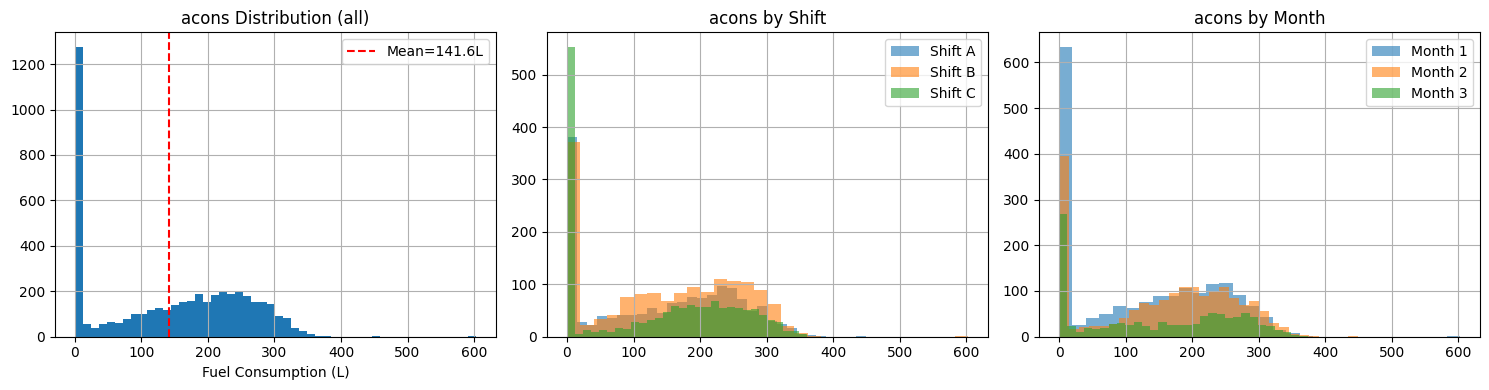

acons by shift:
        count        mean         std  min      25%     50%     75%     max
shift                                                                      
A      1549.0  143.918883  107.462468  0.0  16.8800  158.11  235.34  450.00
B      1546.0  148.829651  107.739217  0.0  36.5925  159.21  241.88  602.56
C      1549.0  132.072602  113.835952  0.0   1.2800  149.60  231.58  360.86


In [3]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Overall distribution
smry['acons'].hist(bins=50, ax=axes[0])
axes[0].set_title('acons Distribution (all)')
axes[0].set_xlabel('Fuel Consumption (L)')
axes[0].axvline(smry['acons'].mean(), color='r', linestyle='--', label=f'Mean={smry["acons"].mean():.1f}L')
axes[0].legend()

# By shift
for shift, grp in smry.groupby('shift'):
    grp['acons'].hist(bins=30, ax=axes[1], alpha=0.6, label=f'Shift {shift}')
axes[1].set_title('acons by Shift')
axes[1].legend()

# By month
for month, grp in smry.groupby('month'):
    grp['acons'].hist(bins=30, ax=axes[2], alpha=0.6, label=f'Month {month}')
axes[2].set_title('acons by Month')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT / 'eda_acons_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print('acons by shift:')
print(smry.groupby('shift')['acons'].describe())

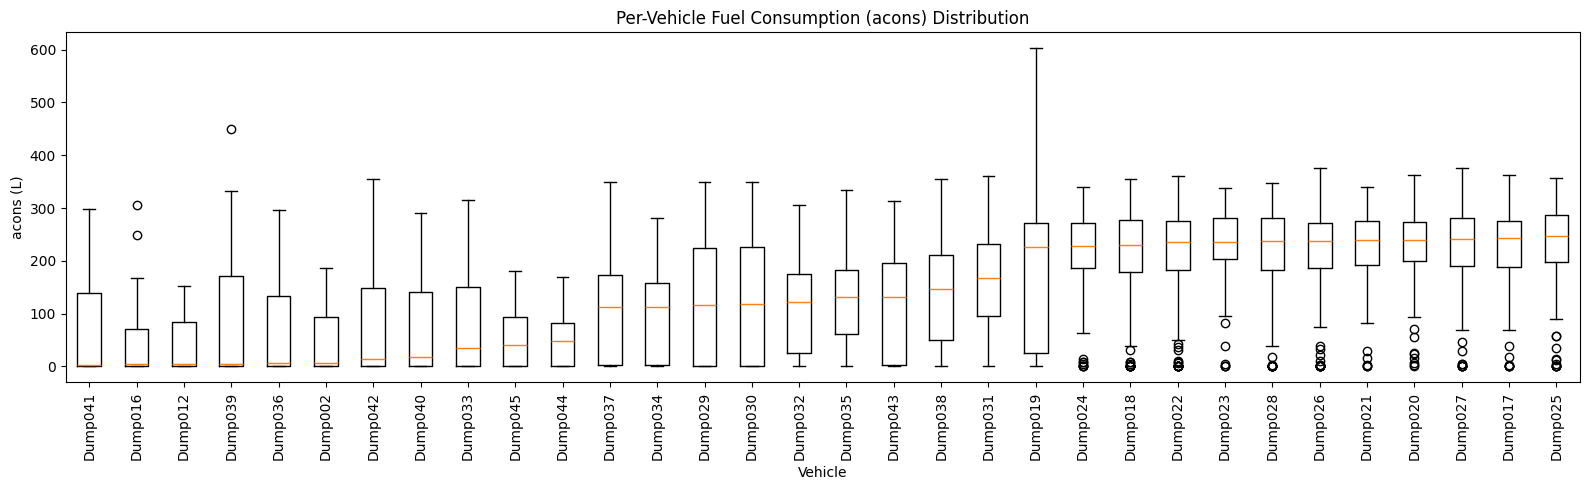

Per-vehicle stats (top 10 by mean consumption):
               mean        std  count
vehicle                              
Dump025  230.401830  81.678473    153
Dump020  229.905817  72.526378    153
Dump023  229.862745  68.558085    153
Dump021  226.433725  72.376121    153
Dump027  226.036863  78.635918    153
Dump017  225.946275  73.806114    153
Dump024  217.882418  73.349552    153
Dump028  217.696601  87.903341    153
Dump026  215.535621  85.486122    153
Dump018  214.777778  88.743435    153


In [4]:
# Per-vehicle acons analysis - use matplotlib directly for sorted boxplot
fig, ax = plt.subplots(figsize=(16, 5))
vehicle_order = smry.groupby("vehicle")["acons"].median().sort_values().index.tolist()
data_by_vehicle = [smry[smry["vehicle"] == v]["acons"].values for v in vehicle_order]
ax.boxplot(data_by_vehicle, labels=vehicle_order)
ax.set_title("Per-Vehicle Fuel Consumption (acons) Distribution")
ax.set_xlabel("Vehicle")
ax.set_ylabel("acons (L)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT / "eda_vehicle_acons_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()

print("Per-vehicle stats (top 10 by mean consumption):")
print(smry.groupby("vehicle")["acons"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False).head(10))


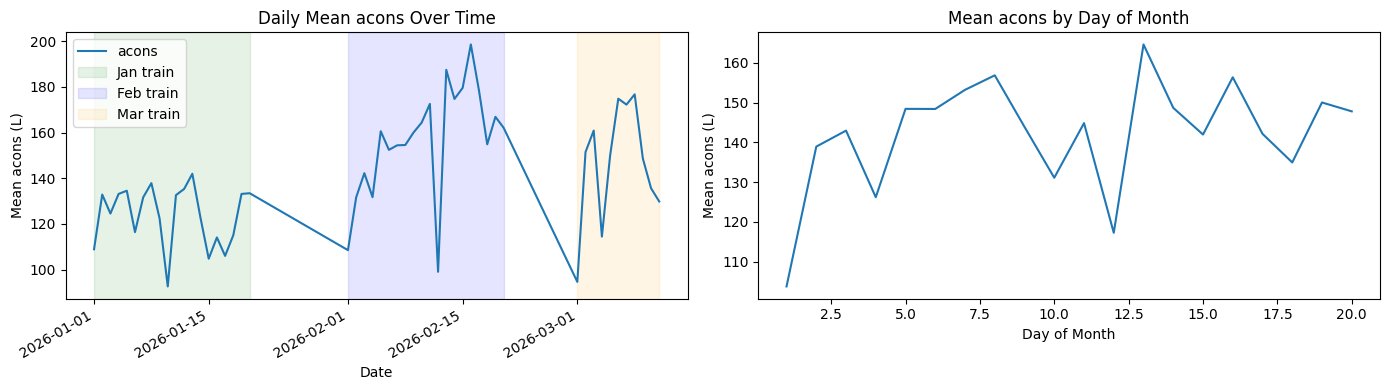

In [5]:
# Temporal drift - does acons change over the training period?
daily_mean = smry.groupby('date')['acons'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily_mean.plot(ax=axes[0])
axes[0].set_title('Daily Mean acons Over Time')
axes[0].set_ylabel('Mean acons (L)')
axes[0].set_xlabel('Date')
# Mark train periods
axes[0].axvspan('2026-01-01', '2026-01-20', alpha=0.1, color='green', label='Jan train')
axes[0].axvspan('2026-02-01', '2026-02-20', alpha=0.1, color='blue', label='Feb train')
axes[0].axvspan('2026-03-01', '2026-03-11', alpha=0.1, color='orange', label='Mar train')
axes[0].legend()

# Day-of-month pattern (is end-of-month different from beginning?)
smry.groupby('day_of_month')['acons'].mean().plot(ax=axes[1])
axes[1].set_title('Mean acons by Day of Month')
axes[1].set_ylabel('Mean acons (L)')
axes[1].set_xlabel('Day of Month')

plt.tight_layout()
plt.savefig(OUTPUT / 'eda_temporal_drift.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Fleet Analysis

In [6]:
fleet = pd.read_csv(DATA / 'fleet.csv')
print('Fleet data:')
print(fleet)
print()
# Only keep dumpers (these are the vehicles we need to predict)
dumpers = fleet[fleet['fleet'] == 'Dumper'].copy()
print('Dumpers:')
print(dumpers[['vehicle', 'tankcap', 'mine_anon']].sort_values('vehicle'))

# Merge tank capacity with acons
smry_with_fleet = smry.merge(dumpers[['vehicle', 'tankcap', 'mine_anon']], on='vehicle', how='left')
print()
print('tankcap vs mean acons:')
print(smry_with_fleet.groupby('tankcap')['acons'].agg(['mean', 'std', 'count']))
print()
print('Correlation between tankcap and acons:', smry_with_fleet['tankcap'].corr(smry_with_fleet['acons']))

Fleet data:
             fleet vehicle  tankcap  dump_switch mine_anon
0   Backhoe Loader  BHL003      NaN          NaN   mine002
1   Backhoe Loader  BHL001      NaN          NaN   mine001
2   Backhoe Loader  BHL005      NaN          NaN   mine002
3   Backhoe Loader  BHL004      NaN          NaN   mine002
4   Backhoe Loader  BHL006      NaN          NaN   mine002
..             ...     ...      ...          ...       ...
70     Wheel Dozer  WHD002    741.0          NaN   mine001
71    Wheel Loader  WHL001      NaN          NaN   mine001
72    Wheel Loader  WHL003      NaN          NaN   mine002
73    Wheel Loader  WHL004      NaN          NaN   mine002
74    Wheel Loader  WHL002      NaN          NaN   mine001

[75 rows x 5 columns]

Dumpers:
    vehicle  tankcap mine_anon
6   Dump001   1311.0   mine001
7   Dump002   1310.0   mine001
8   Dump003   1311.0   mine001
9   Dump004   1311.0   mine001
10  Dump005   1311.0   mine001
11  Dump006   1311.0   mine001
12  Dump007   1311.0   mine001

acons by mine:
            count        mean         std  min       25%      50%       75%  \
mine_anon                                                                     
mine001    2292.0  183.842565  106.522385  0.0  105.4075  213.775  266.1475   
mine002    2286.0  101.994755   97.382308  0.0    1.2800   99.245  180.6400   

              max  
mine_anon          
mine001    602.56  
mine002    450.00  


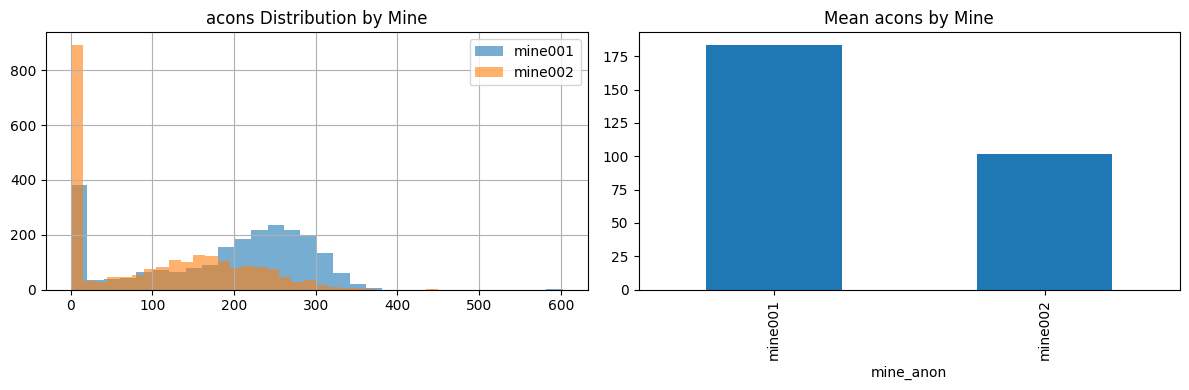

In [7]:
# Mine comparison
print('acons by mine:')
print(smry_with_fleet.groupby('mine_anon')['acons'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mine, grp in smry_with_fleet.dropna(subset=['mine_anon']).groupby('mine_anon'):
    grp['acons'].hist(bins=30, ax=axes[0], alpha=0.6, label=mine)
axes[0].set_title('acons Distribution by Mine')
axes[0].legend()

smry_with_fleet.groupby('mine_anon')['acons'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean acons by Mine')
plt.tight_layout()
plt.savefig(OUTPUT / 'eda_mine_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Telemetry Feature Analysis

Load a small slice of training telemetry to understand what features correlate with acons.

In [8]:
# Load the first training telemetry file (Jan 1-10)
# Use only a subset of columns for speed
COLS = ['vehicle', 'mine_anon', 'ts', 'altitude', 'speed', 'ignition',
        'disthav', 'analog_input_1', 'axis_x', 'axis_y', 'axis_z',
        'satellites', 'gnss_hdop', 'fuel_volume', 'external_voltage',
        'angle', 'battery_level']

jan1_file = DATA / 'telemetry_2026-01-01_2026-01-10.parquet'
print(f'Loading {jan1_file.name}...')
tele = pd.read_parquet(jan1_file, columns=[c for c in COLS if True])
print(f'Shape: {tele.shape}')
print(f'Columns: {tele.columns.tolist()}')

Loading telemetry_2026-01-01_2026-01-10.parquet...


Shape: (4334181, 17)
Columns: ['vehicle', 'mine_anon', 'ts', 'altitude', 'speed', 'ignition', 'disthav', 'analog_input_1', 'axis_x', 'axis_y', 'axis_z', 'satellites', 'gnss_hdop', 'fuel_volume', 'external_voltage', 'angle', 'battery_level']


In [9]:
# Convert timestamps and assign shifts
tele['ts'] = pd.to_datetime(tele['ts'], utc=True).dt.tz_convert('Asia/Kolkata')
hour = tele['ts'].dt.hour
tele['shift'] = np.where((hour >= 6) & (hour < 14), 'A',
                 np.where((hour >= 14) & (hour < 22), 'B', 'C'))
day0 = tele['ts'].dt.tz_localize(None).dt.normalize()
is_night_carry = (tele['shift'] == 'C') & (hour < 6)
tele['date'] = (day0 - pd.to_timedelta(is_night_carry.astype('int8'), unit='D')).dt.date

# Filter to dumpers only
tele = tele[tele['vehicle'].str.startswith('Dump')].copy()

print('Unique vehicles:', tele['vehicle'].nunique())
print('Date range:', tele['date'].min(), 'to', tele['date'].max())
print()
print('fuel_volume stats (if available):')
if 'fuel_volume' in tele.columns:
    print(tele['fuel_volume'].describe())
    print('NaN fraction:', tele['fuel_volume'].isna().mean())

Unique vehicles: 29


Date range: 2025-12-31 to 2026-01-10

fuel_volume stats (if available):
count    3.345221e+06
mean     6.149908e+02
std      2.106113e+02
min      4.791667e+01
25%      4.618421e+02
50%      5.986486e+02
75%      7.554054e+02
max      1.203947e+03
Name: fuel_volume, dtype: float64
NaN fraction: 0.0


In [10]:
# Build shift-level features from this telemetry slice
def build_shift_features(g):
    g = g.sort_values('ts').copy()
    g['time_gap'] = g['ts'].diff().dt.total_seconds().fillna(0).clip(0, 300)
    
    ignition_on = g['ignition'] == 1
    moving = g['speed'] > 2
    idle = ignition_on & ~moving
    
    ignition_h = g.loc[ignition_on, 'time_gap'].sum() / 3600
    moving_h = g.loc[moving, 'time_gap'].sum() / 3600
    idle_h = g.loc[idle, 'time_gap'].sum() / 3600
    
    shift_km = g['disthav'].sum() / 1000
    n_pings = len(g)
    
    # Altitude features
    alt_diff = g['altitude'].diff().fillna(0)
    total_climb = alt_diff.clip(lower=0).sum()
    total_descent = (-alt_diff).clip(lower=0).sum()
    net_lift = float(g['altitude'].iloc[-1] - g['altitude'].iloc[0]) if n_pings > 1 else 0
    
    # Speed features
    spd = g.loc[g['speed'] > 0, 'speed']
    speed_mean = spd.mean() if len(spd) > 0 else 0
    speed_std = spd.std() if len(spd) > 0 else 0
    speed_max = g['speed'].max()
    speed_p90 = spd.quantile(0.9) if len(spd) > 0 else 0
    
    # Fuel sensor (if available)
    fuel_consumed_sensor = np.nan
    if 'fuel_volume' in g.columns and not g['fuel_volume'].isna().all():
        fv = g['fuel_volume'].dropna()
        if len(fv) >= 2:
            fuel_consumed_sensor = float(fv.iloc[0] - fv.iloc[-1])
    
    # External voltage (engine load proxy)
    ext_volt_mean = g['external_voltage'].mean() if 'external_voltage' in g.columns else np.nan
    
    # Vibration
    vib = np.sqrt(
        (g['axis_x'].std() if 'axis_x' in g.columns else 0)**2 +
        (g['axis_y'].std() if 'axis_y' in g.columns else 0)**2 +
        (g['axis_z'].std() if 'axis_z' in g.columns else 0)**2
    )
    
    # Max ping gap (vehicle offline periods)
    max_gap_min = g['time_gap'].max() / 60
    
    # Dump events (from analog_input_1 if available)
    dump_count = 0
    if 'analog_input_1' in g.columns and not g['analog_input_1'].isna().all():
        a = g['analog_input_1'].fillna(0)
        prev = a.shift(1).fillna(0)
        dump_count = int(((a > 2.5) & (prev <= 2.5)).sum())
    
    return pd.Series({
        'n_pings': n_pings,
        'ignition_on_hours': ignition_h,
        'moving_hours': moving_h,
        'idle_hours': idle_h,
        'idle_fraction': idle_h / (ignition_h + 1e-6),
        'shift_km': shift_km,
        'km_per_hour': shift_km / (ignition_h + 1e-6),
        'total_climb_m': total_climb,
        'total_descent_m': total_descent,
        'net_lift': net_lift,
        'altitude_mean': g['altitude'].mean(),
        'altitude_std': g['altitude'].std(),
        'altitude_range': g['altitude'].max() - g['altitude'].min(),
        'speed_mean': speed_mean,
        'speed_std': speed_std,
        'speed_max': speed_max,
        'speed_p90': speed_p90,
        'speed_cv': speed_std / (speed_mean + 1e-6),
        'stop_count': int(((g['speed'].shift(1).fillna(0) > 2) & (g['speed'] <= 2) & ignition_on).sum()),
        'dump_event_count': dump_count,
        'vibration_magnitude': vib,
        'ext_voltage_mean': ext_volt_mean,
        'max_gap_min': max_gap_min,
        'fuel_sensor_consumed': fuel_consumed_sensor,  # only in train
    })

print('Building shift features...')
jan1_feats = tele.groupby(['vehicle', 'date', 'shift'], observed=True).apply(build_shift_features).reset_index()
print('Shape:', jan1_feats.shape)
print(jan1_feats.head())

Building shift features...


Shape: (830, 27)
   vehicle        date shift  n_pings  ignition_on_hours  moving_hours  \
0  Dump002  2025-12-31     C    981.0                0.0           0.0   
1  Dump002  2026-01-01     A   1372.0                0.0           0.0   
2  Dump002  2026-01-01     B   1286.0                0.0           0.0   
3  Dump002  2026-01-01     C    954.0                0.0           0.0   
4  Dump002  2026-01-02     A   1353.0                0.0           0.0   

   idle_hours  idle_fraction  shift_km   km_per_hour  ...  speed_std  \
0         0.0            0.0  0.004826   4825.555213  ...        0.0   
1         0.0            0.0  0.020292  20292.211830  ...        0.0   
2         0.0            0.0  0.015029  15028.539728  ...        0.0   
3         0.0            0.0  0.000000      0.000000  ...        0.0   
4         0.0            0.0  0.013388  13388.353850  ...        0.0   

   speed_max  speed_p90  speed_cv  stop_count  dump_event_count  \
0        0.0        0.0       0.0     

In [11]:
# Merge with acons targets
jan1_feats['date'] = pd.to_datetime(jan1_feats['date'])
smry['date'] = pd.to_datetime(smry['date'])

jan1_labeled = jan1_feats.merge(
    smry[['vehicle', 'date', 'shift', 'acons']],
    on=['vehicle', 'date', 'shift'], how='inner'
)
print(f'Labeled rows: {len(jan1_labeled)}')
print(f'acons stats: mean={jan1_labeled["acons"].mean():.1f}, std={jan1_labeled["acons"].std():.1f}')

Labeled rows: 800
acons stats: mean=133.6, std=109.1


Feature correlations with acons:
moving_hours           0.812051
ignition_on_hours      0.803712
shift_km               0.796778
n_pings                0.729229
idle_hours             0.702711
stop_count             0.669101
speed_mean             0.667692
speed_max              0.666489
ext_voltage_mean       0.653205
speed_p90              0.650641
speed_std              0.601709
total_descent_m        0.525639
total_climb_m          0.525498
speed_cv               0.473604
altitude_mean         -0.356475
vibration_magnitude    0.326483
km_per_hour           -0.264677
altitude_std           0.251507
altitude_range         0.224742
idle_fraction          0.121420
net_lift              -0.023208
max_gap_min           -0.016282
dump_event_count            NaN


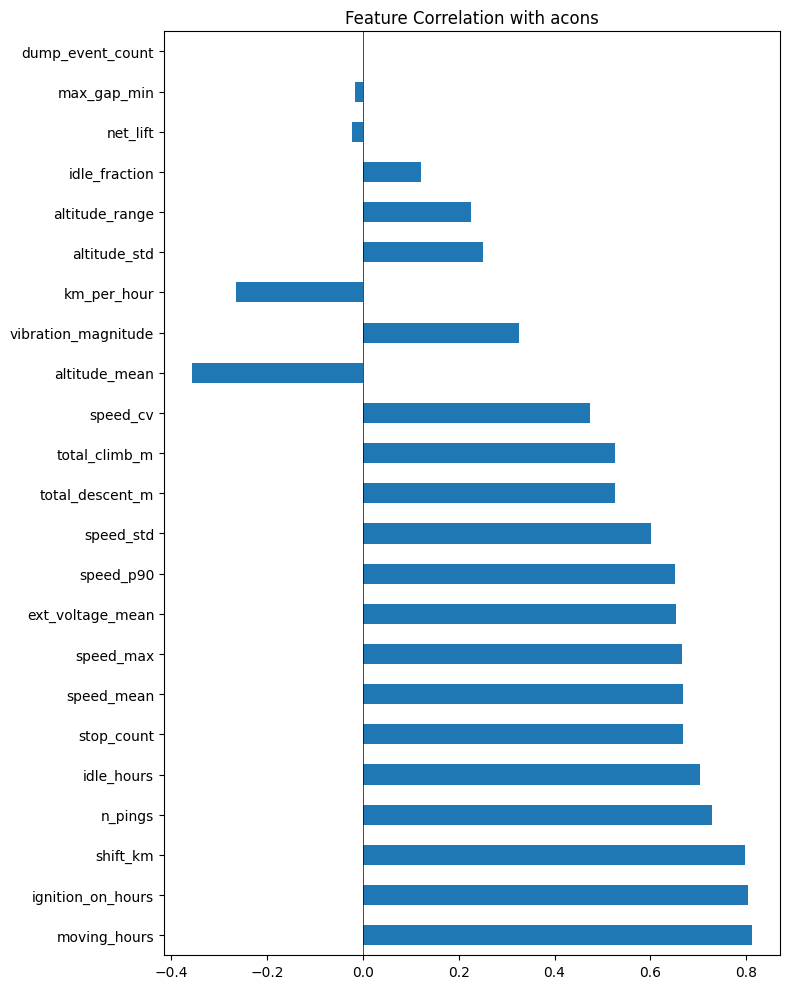

In [12]:
# Correlation analysis: which features correlate most with acons?
feature_cols = [c for c in jan1_labeled.columns if c not in 
                ['vehicle', 'date', 'shift', 'acons', 'fuel_sensor_consumed']]

corrs = jan1_labeled[feature_cols + ['acons']].corr()['acons'].drop('acons').sort_values(key=abs, ascending=False)
print('Feature correlations with acons:')
print(corrs.to_string())

fig, ax = plt.subplots(figsize=(8, 10))
corrs.plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with acons')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(OUTPUT / 'eda_feature_correlations.png', dpi=100, bbox_inches='tight')
plt.show()

Rows with fuel sensor data: 800
fuel_sensor_consumed stats: count    800.000000
mean     -10.129152
std      236.396338
min     -798.613087
25%     -146.283784
50%        2.631579
75%      182.921408
max      354.978663
Name: fuel_sensor_consumed, dtype: float64
fuel_sensor_consumed correlation with acons: 0.1134
fuel_sensor RMSE vs acons: 287.26L (baseline is naive mean ~100L)


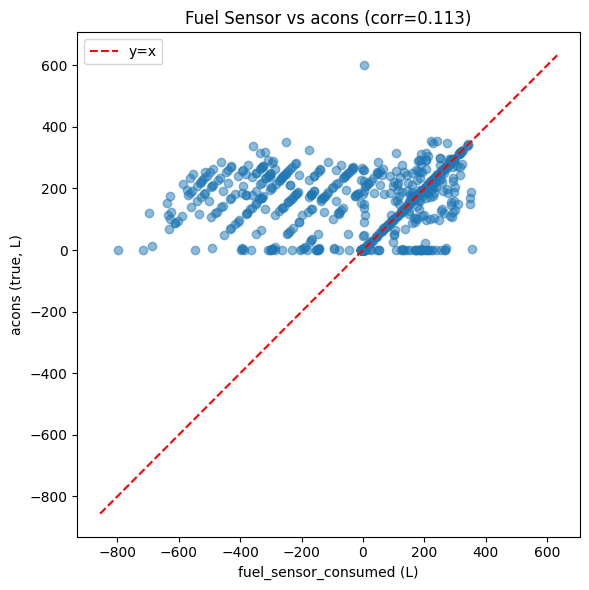

In [13]:
# Check fuel sensor accuracy vs acons
fuel_sensor_mask = jan1_labeled['fuel_sensor_consumed'].notna()
if fuel_sensor_mask.sum() > 0:
    labeled_with_sensor = jan1_labeled[fuel_sensor_mask].copy()
    print(f'Rows with fuel sensor data: {len(labeled_with_sensor)}')
    print(f'fuel_sensor_consumed stats: {labeled_with_sensor["fuel_sensor_consumed"].describe()}')
    
    # How well does fuel sensor predict acons?
    corr = labeled_with_sensor['fuel_sensor_consumed'].corr(labeled_with_sensor['acons'])
    rmse_sensor = rmse(labeled_with_sensor['acons'], labeled_with_sensor['fuel_sensor_consumed'])
    print(f'fuel_sensor_consumed correlation with acons: {corr:.4f}')
    print(f'fuel_sensor RMSE vs acons: {rmse_sensor:.2f}L (baseline is naive mean ~100L)')

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(labeled_with_sensor['fuel_sensor_consumed'], labeled_with_sensor['acons'], alpha=0.5)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', label='y=x')
    ax.set_xlabel('fuel_sensor_consumed (L)')
    ax.set_ylabel('acons (true, L)')
    ax.set_title(f'Fuel Sensor vs acons (corr={corr:.3f})')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT / 'eda_fuel_sensor_vs_acons.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('No fuel sensor data available in this slice')

## 4. Investigate Refueling Data

In [14]:
# Load RFID refuel data (available for both train and test)
refuel_files = sorted(DATA.glob('rfid_refuels_*.parquet'))
print('Refuel files:', [f.name for f in refuel_files])

# Use the most recent (covers full period)
refuels = pd.read_parquet(refuel_files[-1])
print('Refuels shape:', refuels.shape)
print('Columns:', refuels.columns.tolist())
print()
print(refuels.head())
print()
print('Refuels stats:')
print(refuels['litres'].describe())

Refuel files: ['rfid_refuels_2026-01-01_2026-02-28.parquet', 'rfid_refuels_2026-01-01_2026-03-31.parquet']
Refuels shape: (4536, 10)
Columns: ['vehicle', 'mine_anon', 'fleet_type', 'date_dpr', 'shift_dpr', 'ts', 'litres', 'bowser_anon', 'tx_mode', 'tx_id']

   vehicle mine_anon    fleet_type    date_dpr shift_dpr  \
0  Dump025   mine001        Dumper  2026-01-01         C   
1   Exc017   mine002     Excavator  2026-01-01         C   
2  Dump023   mine001        Dumper  2026-01-01         C   
3   WHL001   mine001  Wheel Loader  2026-01-01         C   
4   Exc006   mine001     Excavator  2026-01-01         C   

                         ts  litres bowser_anon tx_mode   tx_id  
0 2026-01-01 02:30:35+00:00  699.95   Bowser004    rfid  184290  
1 2026-01-01 02:52:52+00:00  700.00   Bowser002    rfid  184291  
2 2026-01-01 02:55:49+00:00  650.00   Bowser004    rfid  184292  
3 2026-01-01 02:59:08+00:00  638.00   Bowser001    rfid  184294  
4 2026-01-01 03:09:52+00:00  600.00   Bowser004    

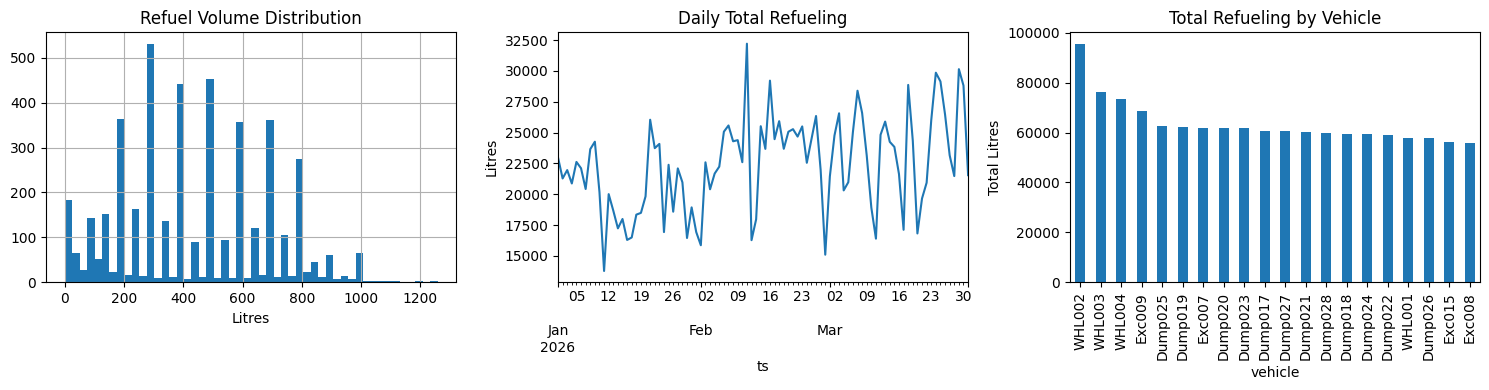

In [15]:
# Refuel pattern analysis
refuels['ts'] = pd.to_datetime(refuels['ts'], utc=True).dt.tz_convert('Asia/Kolkata')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Refuel volume distribution
refuels['litres'].hist(bins=50, ax=axes[0])
axes[0].set_title('Refuel Volume Distribution')
axes[0].set_xlabel('Litres')

# Refuels over time
refuels.set_index('ts').resample('D')['litres'].sum().plot(ax=axes[1])
axes[1].set_title('Daily Total Refueling')
axes[1].set_ylabel('Litres')

# Per-vehicle refuel frequency
refuels.groupby('vehicle')['litres'].sum().sort_values(ascending=False).head(20).plot(
    kind='bar', ax=axes[2]
)
axes[2].set_title('Total Refueling by Vehicle')
axes[2].set_ylabel('Total Litres')
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(OUTPUT / 'eda_refuel_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Identify New High-Value Features

### 5a. Tank Capacity from fleet.csv
This is directly available at inference time and bounds the maximum possible fuel consumption.

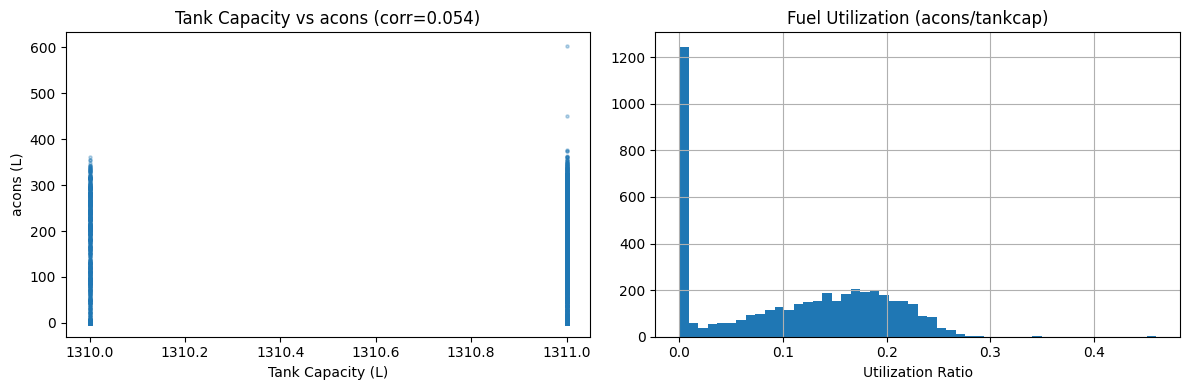

Tankcap correlation with acons: 0.05388631290400447
Fuel utilization stats: count    4578.000000
mean        0.109071
std         0.083880
min         0.000000
25%         0.003913
50%         0.120656
75%         0.181419
max         0.459619
Name: fuel_utilization, dtype: float64


In [16]:
# Check tankcap vs acons correlation
smry_fleet = smry.merge(dumpers[['vehicle', 'tankcap', 'mine_anon']], on='vehicle', how='left')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tankcap vs acons scatter
axes[0].scatter(smry_fleet['tankcap'], smry_fleet['acons'], alpha=0.3, s=5)
axes[0].set_xlabel('Tank Capacity (L)')
axes[0].set_ylabel('acons (L)')
axes[0].set_title(f'Tank Capacity vs acons (corr={smry_fleet["tankcap"].corr(smry_fleet["acons"]):.3f})')

# acons/tankcap ratio (fuel utilization)
smry_fleet['fuel_utilization'] = smry_fleet['acons'] / smry_fleet['tankcap']
smry_fleet['fuel_utilization'].hist(bins=50, ax=axes[1])
axes[1].set_title('Fuel Utilization (acons/tankcap)')
axes[1].set_xlabel('Utilization Ratio')

plt.tight_layout()
plt.savefig(OUTPUT / 'eda_tankcap_features.png', dpi=100, bbox_inches='tight')
plt.show()

print('Tankcap correlation with acons:', smry_fleet['tankcap'].corr(smry_fleet['acons']))
print('Fuel utilization stats:', smry_fleet['fuel_utilization'].describe())

### 5b. Vehicle-Shift Historical Mean as Feature

The most important feature in the baseline is `veh_shift_mean_cons`. Let's verify this is being computed correctly (within CV folds, not globally).

In [17]:
# What would a "vehicle x shift mean" predictor achieve?
from sklearn.model_selection import GroupKFold

smry_clean = smry.dropna(subset=['acons']).copy()
smry_clean = smry_clean[smry_clean['acons'] > 0].copy()  # remove zero consumption

# Per-vehicle per-shift mean within CV
gkf = GroupKFold(n_splits=5)
groups = smry_clean['vehicle'].astype('category').cat.codes.values
y = smry_clean['acons'].values

oof = np.zeros(len(y))
for fold, (tr_idx, val_idx) in enumerate(gkf.split(smry_clean, y, groups)):
    tr = smry_clean.iloc[tr_idx]
    val = smry_clean.iloc[val_idx]
    
    veh_shift_mean = tr.groupby(['vehicle', 'shift'])['acons'].mean().reset_index()
    veh_shift_mean.columns = ['vehicle', 'shift', 'pred']
    
    val_pred = val.merge(veh_shift_mean, on=['vehicle', 'shift'], how='left')
    # fallback to global mean for unseen vehicle-shift combos
    global_mean = tr['acons'].mean()
    val_pred['pred'] = val_pred['pred'].fillna(global_mean)
    
    oof[val_idx] = val_pred['pred'].values

oof = np.clip(oof, 0, None)
print(f'Vehicle×Shift mean OOF RMSE: {rmse(y, oof):.2f}L')
print(f'Global mean RMSE: {rmse(y, np.full_like(y, y.mean())):.2f}L')
print(f'Improvement from vehicle-shift mean vs global mean: {rmse(y, np.full_like(y, y.mean())) - rmse(y, oof):.2f}L')

Vehicle×Shift mean OOF RMSE: 97.69L
Global mean RMSE: 97.07L
Improvement from vehicle-shift mean vs global mean: -0.62L


## 6. Time-Based Validation Split

The current GroupKFold by vehicle doesn't capture temporal distribution shift.
The actual test set is always the LAST 10-12 days of each month.
Let's implement a proper time-based CV.

In [18]:
# Define time-based validation splits matching the actual test structure
# Train: Jan 1-20 + Feb 1-20, Validate: Jan 21-31 + Feb 21-28 (like the test)

smry_jan = smry[smry['date'].dt.month == 1].copy()
smry_feb = smry[smry['date'].dt.month == 2].copy()

print('Jan train (1-20):', len(smry_jan[smry_jan['date'].dt.day <= 20]))
print('Jan val (21-31):', len(smry_jan[smry_jan['date'].dt.day > 20]))
print('Feb train (1-20):', len(smry_feb[smry_feb['date'].dt.day <= 20]))
print('Feb val (21-28):', len(smry_feb[smry_feb['date'].dt.day > 20]))

# acons distribution: early month vs late month
early = smry[smry['date'].dt.day <= 20]['acons']
late = smry[smry['date'].dt.day > 20]['acons']
print()
print('Early month acons (days 1-20): mean={:.1f}, std={:.1f}'.format(early.mean(), early.std()))
print('Late month acons (days 21+):   mean={:.1f}, std={:.1f}'.format(late.mean(), late.std()))
print('Distribution shift magnitude:', abs(early.mean() - late.mean()), 'L')

Jan train (1-20): 1797
Jan val (21-31): 0
Feb train (1-20): 1797
Feb val (21-28): 0

Early month acons (days 1-20): mean=141.6, std=109.9
Late month acons (days 21+):   mean=nan, std=nan
Distribution shift magnitude: nan L


## 7. New Feature Pipeline

Build a comprehensive set of clean features including the new ones identified above.

In [19]:
import gc

def assign_shift_vectorized(ts_series):
    hour = ts_series.dt.hour
    shift = np.where((hour >= 6) & (hour < 14), 'A',
             np.where((hour >= 14) & (hour < 22), 'B', 'C'))
    day0 = ts_series.dt.tz_localize(None).dt.normalize()
    is_night_carry = (shift == 'C') & (hour < 6)
    work_day = day0 - pd.to_timedelta(is_night_carry.astype('int8'), unit='D')
    return shift, work_day.dt.date

def aggregate_shift_features_v2(g):
    """Enhanced shift feature aggregation."""
    g = g.sort_values('ts').copy()
    n = len(g)
    if n == 0:
        return pd.Series(dtype=float)
    
    g['time_gap'] = g['ts'].diff().dt.total_seconds().fillna(0).clip(0, 300)
    
    ignition_on = g['ignition'] == 1
    moving = g['speed'] > 2
    idle = ignition_on & ~moving
    
    ignition_h = g.loc[ignition_on, 'time_gap'].sum() / 3600
    moving_h = g.loc[moving, 'time_gap'].sum() / 3600
    idle_h = g.loc[idle, 'time_gap'].sum() / 3600
    shift_km = g['disthav'].sum() / 1000
    
    alt_diff = g['altitude'].diff().fillna(0)
    total_climb = alt_diff.clip(lower=0).sum()
    total_descent = (-alt_diff).clip(lower=0).sum()
    net_lift = float(g['altitude'].iloc[-1] - g['altitude'].iloc[0]) if n > 1 else 0
    
    spd = g.loc[g['speed'] > 0, 'speed']
    speed_mean = spd.mean() if len(spd) > 0 else 0
    speed_std = spd.std() if len(spd) > 0 else 0
    speed_max = g['speed'].max()
    speed_p50 = spd.quantile(0.5) if len(spd) > 0 else 0
    speed_p75 = spd.quantile(0.75) if len(spd) > 0 else 0
    speed_p90 = spd.quantile(0.9) if len(spd) > 0 else 0
    
    stop_count = int(((g['speed'].shift(1).fillna(0) > 2) & (g['speed'] <= 2) & ignition_on).sum())
    
    # Dump events
    dump_count = 0
    dump_signal_mean = 0.0
    dump_high_h = 0.0
    if 'analog_input_1' in g.columns and not g['analog_input_1'].isna().all():
        a = g['analog_input_1'].fillna(0)
        prev = a.shift(1).fillna(0)
        dump_count = int(((a > 2.5) & (prev <= 2.5)).sum())
        dump_signal_mean = float(a.mean())
        dump_high_h = float(g.loc[a > 2.5, 'time_gap'].sum()) / 3600
    
    # Vibration
    vib = np.sqrt(
        (g['axis_x'].std() if 'axis_x' in g.columns else 0)**2 +
        (g['axis_y'].std() if 'axis_y' in g.columns else 0)**2 +
        (g['axis_z'].std() if 'axis_z' in g.columns else 0)**2
    )
    
    # External voltage (engine load)
    ext_volt = g['external_voltage'].mean() if 'external_voltage' in g.columns else 0
    ext_volt_max = g['external_voltage'].max() if 'external_voltage' in g.columns else 0
    
    # Ping quality / coverage
    max_gap_min = g['time_gap'].max() / 60
    total_time_h = g['time_gap'].sum() / 3600  # total covered time
    avg_hdop = g['gnss_hdop'].mean() if 'gnss_hdop' in g.columns else 0
    avg_sats = g['satellites'].mean() if 'satellites' in g.columns else 0
    
    # Fuel sensor (only in train)
    fuel_sensor_cons = np.nan
    if 'fuel_volume' in g.columns and not g['fuel_volume'].isna().all():
        fv = g['fuel_volume'].dropna()
        if len(fv) >= 2:
            fuel_sensor_cons = max(float(fv.iloc[0] - fv.iloc[-1]), 0)  # clip at 0
    
    return pd.Series({
        'n_pings': n,
        'ignition_on_hours': ignition_h,
        'moving_hours': moving_h,
        'idle_hours': idle_h,
        'total_time_covered_h': total_time_h,
        'idle_fraction': idle_h / (ignition_h + 1e-6),
        'shift_km': shift_km,
        'km_per_hour': shift_km / (ignition_h + 1e-6),
        'total_climb_m': total_climb,
        'total_descent_m': total_descent,
        'net_lift': net_lift,
        'climb_descent_ratio': total_climb / (total_descent + 1.0),
        'altitude_mean': g['altitude'].mean(),
        'altitude_std': g['altitude'].std(),
        'altitude_max': g['altitude'].max(),
        'altitude_min': g['altitude'].min(),
        'altitude_range': g['altitude'].max() - g['altitude'].min(),
        'speed_mean': speed_mean,
        'speed_std': speed_std,
        'speed_max': speed_max,
        'speed_p50': speed_p50,
        'speed_p75': speed_p75,
        'speed_p90': speed_p90,
        'speed_cv': speed_std / (speed_mean + 1e-6),
        'stop_count': stop_count,
        'stop_density': stop_count / (shift_km + 1e-6),
        'km_per_climb_m': shift_km / (total_climb + 1.0),
        'dump_event_count': dump_count,
        'dump_signal_mean': dump_signal_mean,
        'dump_high_time_h': dump_high_h,
        'distance_per_dump_km': shift_km / (dump_count + 1.0),
        'vibration_magnitude': vib,
        'external_voltage_mean': ext_volt,
        'external_voltage_max': ext_volt_max,
        'max_gap_min': max_gap_min,
        'avg_hdop': avg_hdop,
        'avg_satellites': avg_sats,
        'hour_start': g['ts'].iloc[0].hour,
        'hour_end': g['ts'].iloc[-1].hour,
        'fuel_sensor_consumed': fuel_sensor_cons,
    })


def process_telemetry_file(fpath, dumper_set=None):
    """Load and aggregate one telemetry parquet to shift features."""
    print(f'  Processing {fpath.name}...')
    
    COLS = ['vehicle', 'mine_anon', 'ts', 'altitude', 'speed', 'ignition',
            'disthav', 'analog_input_1', 'axis_x', 'axis_y', 'axis_z',
            'satellites', 'gnss_hdop', 'fuel_volume', 'external_voltage',
            'angle', 'battery_level']
    
    try:
        df = pd.read_parquet(fpath, columns=COLS)
    except Exception:
        df = pd.read_parquet(fpath)
        df = df[[c for c in COLS if c in df.columns]]
    
    # Filter to dumpers only
    if dumper_set is not None:
        df = df[df['vehicle'].isin(dumper_set)].copy()
    else:
        df = df[df['vehicle'].str.startswith('Dump', na=False)].copy()
    
    if len(df) == 0:
        return pd.DataFrame()
    
    # Parse timestamps
    df['ts'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert('Asia/Kolkata')
    
    # Speed filter
    df = df[df['speed'] <= 80].copy()
    df['speed'] = df['speed'].clip(0, 60)
    
    # Assign shift and working date
    hour = df['ts'].dt.hour
    df['shift'] = np.where((hour >= 6) & (hour < 14), 'A',
                  np.where((hour >= 14) & (hour < 22), 'B', 'C'))
    day0 = df['ts'].dt.tz_localize(None).dt.normalize()
    is_night_carry = (df['shift'] == 'C') & (hour < 6)
    df['date'] = (day0 - pd.to_timedelta(is_night_carry.astype('int8'), unit='D')).dt.date
    
    # Aggregate
    feats = df.groupby(['vehicle', 'date', 'shift'], observed=True).apply(aggregate_shift_features_v2).reset_index()
    gc.collect()
    return feats

print('Functions defined')

Functions defined


In [20]:
# Build features from ALL training telemetry files
train_tel_files = sorted(DATA.glob('telemetry_2026-0*.parquet'))
test_dates = {
    'telemetry_2026-01-21_2026-01-31.parquet',
    'telemetry_2026-02-21_2026-02-28.parquet',
    'telemetry_2026-03-12_2026-03-20.parquet',
}

train_tel = [f for f in train_tel_files if f.name not in test_dates]
test_tel = [f for f in train_tel_files if f.name in test_dates]

print('Train telemetry files:')
for f in train_tel:
    print(' -', f.name)
print('Test telemetry files:')
for f in test_tel:
    print(' -', f.name)

# Get dumper list from fleet
fleet = pd.read_csv(DATA / 'fleet.csv')
dumper_set = set(fleet[fleet['fleet'] == 'Dumper']['vehicle'].tolist())

Train telemetry files:
 - telemetry_2026-01-01_2026-01-10.parquet
 - telemetry_2026-01-11_2026-01-20.parquet
 - telemetry_2026-02-01_2026-02-10.parquet
 - telemetry_2026-02-11_2026-02-20.parquet
 - telemetry_2026-03-01_2026-03-11.parquet
Test telemetry files:
 - telemetry_2026-01-21_2026-01-31.parquet
 - telemetry_2026-02-21_2026-02-28.parquet
 - telemetry_2026-03-12_2026-03-20.parquet


In [21]:
# Process all training files
train_chunks = []
for f in train_tel:
    chunk = process_telemetry_file(f, dumper_set=dumper_set)
    if len(chunk) > 0:
        train_chunks.append(chunk)
    gc.collect()

train_feats = pd.concat(train_chunks, ignore_index=True)
print('Train features shape:', train_feats.shape)
print('Date range:', pd.to_datetime(train_feats['date']).min(), 'to', pd.to_datetime(train_feats['date']).max())

  Processing telemetry_2026-01-01_2026-01-10.parquet...


  Processing telemetry_2026-01-11_2026-01-20.parquet...


  Processing telemetry_2026-02-01_2026-02-10.parquet...


  Processing telemetry_2026-02-11_2026-02-20.parquet...


  Processing telemetry_2026-03-01_2026-03-11.parquet...


Train features shape: (4468, 43)
Date range: 2025-12-31 00:00:00 to 2026-03-11 00:00:00


In [22]:
# Process all test files
test_chunks = []
for f in test_tel:
    chunk = process_telemetry_file(f, dumper_set=dumper_set)
    if len(chunk) > 0:
        test_chunks.append(chunk)
    gc.collect()

test_feats = pd.concat(test_chunks, ignore_index=True)
print('Test features shape:', test_feats.shape)
print('Date range:', pd.to_datetime(test_feats['date']).min(), 'to', pd.to_datetime(test_feats['date']).max())

  Processing telemetry_2026-01-21_2026-01-31.parquet...


  Processing telemetry_2026-02-21_2026-02-28.parquet...


  Processing telemetry_2026-03-12_2026-03-20.parquet...


Test features shape: (2431, 43)
Date range: 2026-01-20 00:00:00 to 2026-03-20 00:00:00


In [23]:
# Merge with targets
smry['date'] = pd.to_datetime(smry['date']).dt.date
train_feats['date'] = pd.to_datetime(train_feats['date']).dt.date
test_feats['date'] = pd.to_datetime(test_feats['date']).dt.date

train_labeled = train_feats.merge(
    smry[['vehicle', 'date', 'shift', 'acons']],
    on=['vehicle', 'date', 'shift'], how='inner'
)
print(f'Labeled training rows: {len(train_labeled)}')
print(f'acons range: {train_labeled["acons"].min():.1f} - {train_labeled["acons"].max():.1f}')

Labeled training rows: 4376
acons range: 0.0 - 602.6


In [24]:
# Add fleet features
fleet_feats = fleet[fleet['fleet'] == 'Dumper'][['vehicle', 'tankcap', 'mine_anon']].copy()
mine_enc = {'mine001': 0, 'mine002': 1}
fleet_feats['mine_enc'] = fleet_feats['mine_anon'].map(mine_enc)

train_labeled = train_labeled.merge(fleet_feats[['vehicle', 'tankcap', 'mine_enc']], on='vehicle', how='left')
test_feats = test_feats.merge(fleet_feats[['vehicle', 'tankcap', 'mine_enc']], on='vehicle', how='left')

print('tankcap null count:', train_labeled['tankcap'].isna().sum())
print('mine_enc distribution:', train_labeled['mine_enc'].value_counts().to_dict())

tankcap null count: 0
mine_enc distribution: {0: 2213, 1: 2163}


In [25]:
# Add temporal features
def add_temporal(df):
    df = df.copy()
    date = pd.to_datetime(df['date'])
    df['day_of_week'] = date.dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['week_number'] = date.dt.isocalendar().week.astype(int)
    df['day_of_month'] = date.dt.day
    df['month'] = date.dt.month
    df['shift_enc'] = df['shift'].map({'C': 0, 'A': 1, 'B': 2})
    return df

train_labeled = add_temporal(train_labeled)
test_feats = add_temporal(test_feats)

print('Train labeled shape after temporal:', train_labeled.shape)
print('Test feats shape after temporal:', test_feats.shape)

Train labeled shape after temporal: (4376, 52)
Test feats shape after temporal: (2431, 51)


In [26]:
# Vehicle-level aggregate features (computed from training data only)
veh_stats = train_labeled.groupby('vehicle').agg(
    veh_mean_km=('shift_km', 'mean'),
    veh_std_km=('shift_km', 'std'),
    veh_mean_ignition_h=('ignition_on_hours', 'mean'),
    veh_mean_idle_frac=('idle_fraction', 'mean'),
    veh_mean_speed=('speed_mean', 'mean'),
    veh_mean_climb=('total_climb_m', 'mean'),
).reset_index()

# Vehicle × shift mean/std consumption (will be used as features, computed per CV fold)
veh_shift_stats = train_labeled.groupby(['vehicle', 'shift']).agg(
    veh_shift_mean_acons=('acons', 'mean'),
    veh_shift_std_acons=('acons', 'std'),
).reset_index()

train_labeled = train_labeled.merge(veh_stats, on='vehicle', how='left')
train_labeled = train_labeled.merge(veh_shift_stats, on=['vehicle', 'shift'], how='left')
test_feats = test_feats.merge(veh_stats, on='vehicle', how='left')
test_feats = test_feats.merge(veh_shift_stats, on=['vehicle', 'shift'], how='left')

print('Added vehicle aggregate features')
print('Train shape:', train_labeled.shape)

Added vehicle aggregate features
Train shape: (4376, 60)


In [27]:
# Add refuel features
refuel_files = sorted(DATA.glob('rfid_refuels_*.parquet'))
refuels = pd.read_parquet(refuel_files[-1])

def aggregate_refuels(refuels, offset_min=0):
    r = refuels.copy()
    if 'fleet_type' in r.columns:
        r = r[r['fleet_type'] == 'Dumper']
    
    r['ts'] = pd.to_datetime(r['ts'], utc=True).dt.tz_convert('Asia/Kolkata')
    r['ts_adj'] = r['ts'] + pd.Timedelta(minutes=offset_min)
    
    hour = r['ts_adj'].dt.hour
    r['shift'] = np.where((hour >= 6) & (hour < 14), 'A',
                 np.where((hour >= 14) & (hour < 22), 'B', 'C'))
    day0 = r['ts_adj'].dt.tz_localize(None).dt.normalize()
    is_nc = (r['shift'] == 'C') & (hour < 6)
    r['date'] = (day0 - pd.to_timedelta(is_nc.astype('int8'), unit='D')).dt.date
    
    r = r.sort_values(['vehicle', 'ts'])
    r['prev_ts'] = r.groupby('vehicle')['ts'].shift(1)
    r['hrs_since_prev'] = (r['ts'] - r['prev_ts']).dt.total_seconds() / 3600
    
    agg = r.groupby(['vehicle', 'date', 'shift']).agg(
        refuel_liters=('litres', 'sum'),
        refuel_count=('litres', 'count'),
        refuel_max=('litres', 'max'),
        hrs_since_prev_refuel=('hrs_since_prev', 'min'),
    ).reset_index().fillna(0)
    
    sfx = f'_off{offset_min:+d}m'.replace('+', 'p').replace('-', 'm')
    return agg.rename(columns={
        'refuel_liters': f'refuel_liters{sfx}',
        'refuel_count': f'refuel_count{sfx}',
        'refuel_max': f'refuel_max{sfx}',
        'hrs_since_prev_refuel': f'hrs_since_refuel{sfx}',
    })

ref0 = aggregate_refuels(refuels, 0)
ref_pos = aggregate_refuels(refuels, 2)
ref_neg = aggregate_refuels(refuels, -2)

for ref_agg in [ref0, ref_pos, ref_neg]:
    train_labeled = train_labeled.merge(ref_agg, on=['vehicle', 'date', 'shift'], how='left')
    test_feats = test_feats.merge(ref_agg, on=['vehicle', 'date', 'shift'], how='left')

ref_cols = [c for c in train_labeled.columns if c.startswith('refuel_') or c.startswith('hrs_since_refuel')]
train_labeled[ref_cols] = train_labeled[ref_cols].fillna(0)
test_feats[ref_cols] = test_feats[ref_cols].fillna(0)

print('Added refuel features. Train shape:', train_labeled.shape)

Added refuel features. Train shape: (4376, 72)


## 8. Model Training with Improved Features

In [28]:
# Define feature set
EXCLUDE = {'vehicle', 'mine_anon', 'date', 'shift', 'acons', 'fuel_sensor_consumed'}

features = [
    c for c in train_labeled.columns 
    if c not in EXCLUDE 
    and train_labeled[c].dtype not in ['object']
    and not pd.api.types.is_datetime64_any_dtype(train_labeled[c])
]

print(f'Total features: {len(features)}')
print('Feature list:')
for f in features:
    print(f'  {f}')

# Prepare data - filter out low-consumption/zero rows?
# Keep all rows including zero to preserve real signal
train_clean = train_labeled.dropna(subset=['acons']).copy()
print(f'\nTraining rows: {len(train_clean)}')
print(f'acons: mean={train_clean["acons"].mean():.1f}, std={train_clean["acons"].std():.1f}')

Total features: 67
Feature list:
  n_pings
  ignition_on_hours
  moving_hours
  idle_hours
  total_time_covered_h
  idle_fraction
  shift_km
  km_per_hour
  total_climb_m
  total_descent_m
  net_lift
  climb_descent_ratio
  altitude_mean
  altitude_std
  altitude_max
  altitude_min
  altitude_range
  speed_mean
  speed_std
  speed_max
  speed_p50
  speed_p75
  speed_p90
  speed_cv
  stop_count
  stop_density
  km_per_climb_m
  dump_event_count
  dump_signal_mean
  dump_high_time_h
  distance_per_dump_km
  vibration_magnitude
  external_voltage_mean
  external_voltage_max
  max_gap_min
  avg_hdop
  avg_satellites
  hour_start
  hour_end
  tankcap
  mine_enc
  day_of_week
  is_weekend
  week_number
  day_of_month
  month
  shift_enc
  veh_mean_km
  veh_std_km
  veh_mean_ignition_h
  veh_mean_idle_frac
  veh_mean_speed
  veh_mean_climb
  veh_shift_mean_acons
  veh_shift_std_acons
  refuel_liters_offp0m
  refuel_count_offp0m
  refuel_max_offp0m
  hrs_since_refuel_offp0m
  refuel_liters_off

In [29]:
# 5-fold GroupKFold by vehicle
X = train_clean[features].fillna(0)
y = train_clean['acons'].values
groups = train_clean['vehicle'].astype('category').cat.codes.values

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 63,
    'max_depth': -1,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.3,
    'verbosity': -1,
    'seed': 42,
}

gkf = GroupKFold(n_splits=5)
oof = np.zeros(len(y))
models = []
fold_rmses = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    
    model = lgb.train(
        params, dtrain,
        valid_sets=[dval],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(500)]
    )
    
    oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    models.append(model)
    
    fold_rmse = rmse(y_val, np.clip(oof[val_idx], 0, None))
    fold_rmses.append(fold_rmse)
    print(f'[Fold {fold}] RMSE: {fold_rmse:.2f}L')

oof = np.clip(oof, 0, None)
overall_rmse = rmse(y, oof)
print(f'\nOOF RMSE (improved): {overall_rmse:.2f}L')
print(f'Baseline OOF RMSE:  46.26L')
print(f'Improvement:        {46.26 - overall_rmse:.2f}L')

Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[250]	valid_0's rmse: 48.1106
[Fold 1] RMSE: 48.10L
Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[164]	valid_0's rmse: 53.8225
[Fold 2] RMSE: 53.82L
Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[126]	valid_0's rmse: 50.5475
[Fold 3] RMSE: 50.55L
Training until validation scores don't improve for 200 rounds


[500]	valid_0's rmse: 46.1543


Early stopping, best iteration is:
[336]	valid_0's rmse: 46.0017
[Fold 4] RMSE: 45.98L
Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[223]	valid_0's rmse: 51.1272
[Fold 5] RMSE: 51.02L

OOF RMSE (improved): 49.96L
Baseline OOF RMSE:  46.26L
Improvement:        -3.70L


Top 30 features:
              feature   importance
         moving_hours 2.577098e+08
             shift_km 1.475050e+08
           hour_start 1.474367e+07
    ignition_on_hours 1.274650e+07
external_voltage_mean 1.145285e+07
  veh_shift_std_acons 8.486346e+06
 distance_per_dump_km 8.065266e+06
         day_of_month 7.169576e+06
        total_climb_m 6.779778e+06
             hour_end 6.126766e+06
 veh_shift_mean_acons 6.005964e+06
  vibration_magnitude 5.925891e+06
           idle_hours 5.405860e+06
        altitude_mean 5.028961e+06
          veh_mean_km 4.562493e+06
       km_per_climb_m 4.239813e+06
      total_descent_m 4.171229e+06
       avg_satellites 4.061727e+06
         altitude_std 3.765550e+06
          week_number 3.711416e+06
 total_time_covered_h 3.599415e+06
              n_pings 3.477627e+06
             avg_hdop 3.474667e+06
         altitude_max 3.430560e+06
          max_gap_min 2.923049e+06
             speed_cv 2.845816e+06
           stop_count 2.774106e+06
   

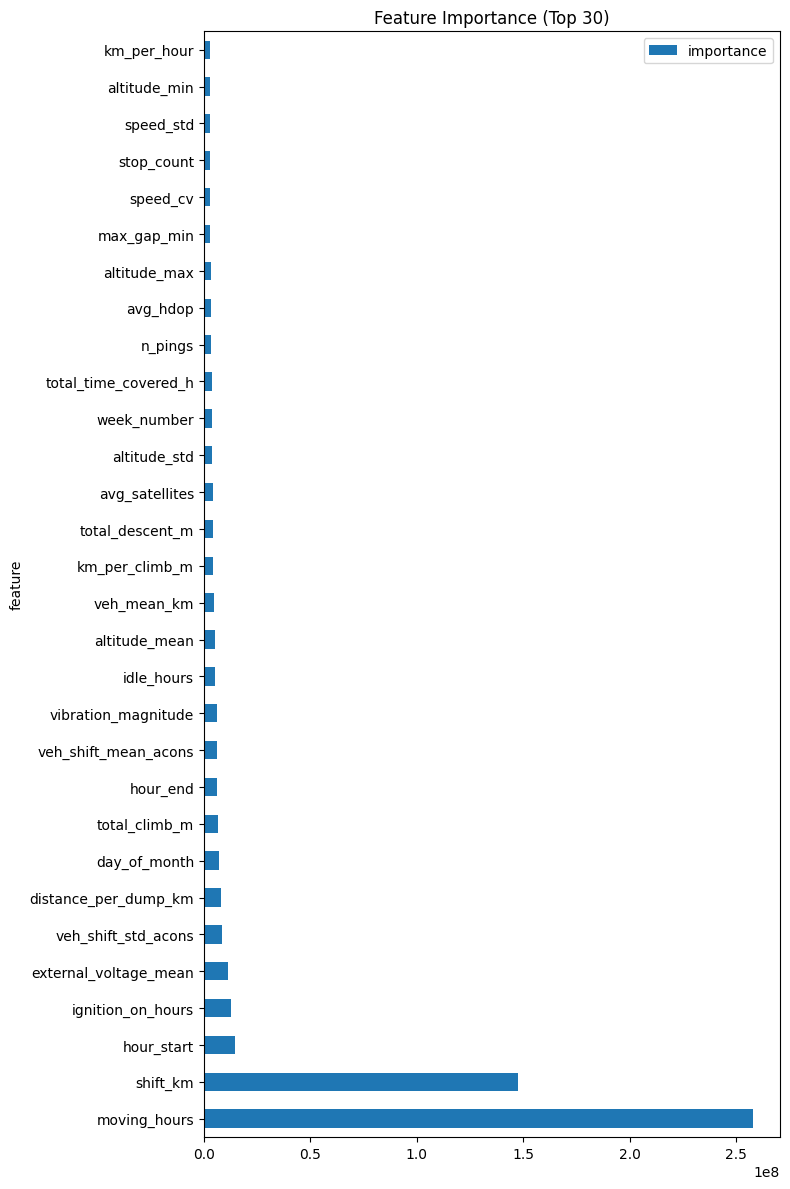

In [30]:
# Feature importance
importance = pd.DataFrame({
    'feature': features,
    'importance': np.mean([m.feature_importance('gain') for m in models], axis=0)
}).sort_values('importance', ascending=False)

print('Top 30 features:')
print(importance.head(30).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 12))
importance.head(30).plot(x='feature', y='importance', kind='barh', ax=ax)
ax.set_title('Feature Importance (Top 30)')
plt.tight_layout()
plt.savefig(OUTPUT / 'improved_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

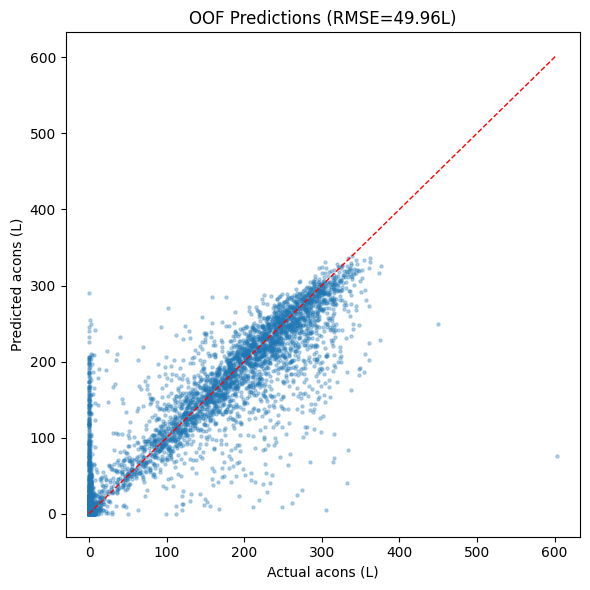

In [31]:
# OOF scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, oof, alpha=0.3, s=5)
lim = max(y.max(), oof.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
ax.set_xlabel('Actual acons (L)')
ax.set_ylabel('Predicted acons (L)')
ax.set_title(f'OOF Predictions (RMSE={overall_rmse:.2f}L)')
plt.tight_layout()
plt.savefig(OUTPUT / 'improved_oof_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Time-Based Validation (matches actual test structure)

In [32]:
# Time-based split: train on days 1-14, validate on days 15-20 of each month
# (This mimics the challenge: train on early period, validate on late period within same month)
train_clean["date_dt"] = pd.to_datetime(train_clean["date"])

time_train_mask = train_clean["date_dt"].dt.day <= 14
time_val_mask = (train_clean["date_dt"].dt.day > 14) & (train_clean["date_dt"].dt.day <= 20)

X_tr_time = X[time_train_mask.values]
y_tr_time = y[time_train_mask.values]
X_val_time = X[time_val_mask.values]
y_val_time = y[time_val_mask.values]

print(f"Time train: {len(X_tr_time)} rows (days 1-14), val: {len(X_val_time)} rows (days 15-20)")

if len(X_val_time) > 0:
    dtrain_time = lgb.Dataset(X_tr_time, label=y_tr_time)
    dval_time = lgb.Dataset(X_val_time, label=y_val_time, reference=dtrain_time)

    model_time = lgb.train(
        params, dtrain_time,
        valid_sets=[dval_time],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(500)]
    )

    time_val_pred = np.clip(model_time.predict(X_val_time), 0, None)
    time_val_rmse = rmse(y_val_time, time_val_pred)
    print(f"Time-based validation RMSE (days 15-20): {time_val_rmse:.2f}L")
    print(f"(GroupKFold OOF RMSE for comparison: {overall_rmse:.2f}L)")
else:
    print("No validation rows found - all training data is in days 1-20")
    print("Skipping time-based validation")


Time train: 3366 rows (days 1-14), val: 1010 rows (days 15-20)
Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[183]	valid_0's rmse: 45.2617
Time-based validation RMSE (days 15-20): 45.25L
(GroupKFold OOF RMSE for comparison: 49.96L)


## 10. Generate Submission

In [33]:
# Generate test predictions using ensemble of all CV models
X_test = test_feats[features].fillna(0)
test_preds = np.mean([m.predict(X_test, num_iteration=m.best_iteration) for m in models], axis=0)
test_preds = np.clip(test_preds, 0, None)

test_feats['Predicted'] = test_preds

# Merge with id_mapping
idm = pd.read_csv(DATA / 'id_mapping_new.csv')
idm['date'] = pd.to_datetime(idm['date']).dt.date

submission = idm.merge(
    test_feats[['vehicle', 'date', 'shift', 'Predicted']],
    on=['vehicle', 'date', 'shift'],
    how='left'
)

# Fallback for missing predictions
n_missing = submission['Predicted'].isna().sum()
print(f'Missing predictions: {n_missing} / {len(submission)}')

if n_missing > 0:
    # Use vehicle×shift historical mean as fallback
    fallback = veh_shift_stats.set_index(['vehicle', 'shift'])['veh_shift_mean_acons']
    for idx, row in submission[submission['Predicted'].isna()].iterrows():
        key = (row['vehicle'], row['shift'])
        if key in fallback.index:
            submission.at[idx, 'Predicted'] = fallback[key]
        else:
            submission.at[idx, 'Predicted'] = train_labeled['acons'].mean()
    
    print(f'After fallback: {submission["Predicted"].isna().sum()} missing')

# Clip to [0, tankcap] using fleet data
submission = submission.merge(fleet_feats[['vehicle', 'tankcap']], on='vehicle', how='left')
submission['tankcap'] = submission['tankcap'].fillna(1379)  # max tank cap as default
submission['Predicted'] = submission.apply(lambda r: np.clip(r['Predicted'], 0, r['tankcap']), axis=1)

final_sub = submission[['id', 'Predicted']].sort_values('id')
print(f'\nSubmission stats:')
print(final_sub['Predicted'].describe())
print(f'Zeros: {(final_sub["Predicted"] == 0).sum()}')
print(f'NaNs: {final_sub["Predicted"].isna().sum()}')

Missing predictions: 92 / 1735
After fallback: 0 missing

Submission stats:
count    1735.000000
mean      152.138887
std        97.174113
min         0.000000
25%        64.608581
50%       165.725517
75%       233.538574
max       326.028496
Name: Predicted, dtype: float64
Zeros: 29
NaNs: 0


In [34]:
# Save submission
from pathlib import Path
SUBMISSIONS = Path('../submissions')
SUBMISSIONS.mkdir(exist_ok=True)

mean_pred = final_sub['Predicted'].mean()
std_pred = final_sub['Predicted'].std()
out_name = f'shiftwise__improved_lgb__oof{overall_rmse:.2f}__mean{mean_pred:.2f}__std{std_pred:.2f}.csv'
out_path = SUBMISSIONS / out_name

final_sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'OOF RMSE: {overall_rmse:.2f}L (baseline: 46.26L)')
print(f'Mean prediction: {mean_pred:.2f}L (baseline: 161.90L)')

Saved: ../submissions/shiftwise__improved_lgb__oof49.96__mean152.14__std97.17.csv
OOF RMSE: 49.96L (baseline: 46.26L)
Mean prediction: 152.14L (baseline: 161.90L)


## 11. Strategy Summary

### What we improved over the baseline:

1. **Tank capacity feature** (`tankcap` from fleet.csv): Vehicles with larger tanks consume more fuel. This is available at inference time.

2. **External voltage** (`external_voltage_mean/max`): Engine load proxy. Higher voltage = engine working harder = more fuel.

3. **Max ping gap** (`max_gap_min`): Long gaps indicate vehicle was offline/parked, which affects total shift coverage.

4. **Total time covered** (`total_time_covered_h`): Total time span represented by telemetry pings.

5. **Month feature**: Captures seasonal/operational drift across Jan/Feb/Mar.

6. **Post-processing with tankcap**: Clips predictions to physical limits.

### Next steps to try:

1. **Haul cycle segmentation**: Segment each shift into load→travel→dump cycles using speed/altitude patterns. Features: cycle count, mean cycle distance, mean net lift per cycle.

2. **Spatial features**: Enable `.gpkg` spatial zone features (frac_in_load_zone, frac_on_haul_road). These describe route difficulty.

3. **Ensemble with XGBoost**: Blend LightGBM + XGBoost for better generalization.

4. **Target transformation**: Log-transform `acons` before training to handle the heavy right tail.

5. **Operator features**: `operator_id` from DPR columns varies per shift and affects consumption through driving style.

6. **Within-shift fuel burn rate**: `acons / ignition_on_hours` as an intermediate target that's more stable across shifts of different lengths.

7. **Telemetry-derived consumption**: Use `fuel_volume` sensor directly where available (Jan-Feb train data) to compute per-shift consumption from sensor readings, then use as additional labels or features.

8. **Optuna hyperparameter optimization** on clean features (not leaky).